In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Introducción
DBSCAN es un algoritmo de clustering que agrupa puntos que están cercanos entre sí, marcando como outliers los puntos que se encuentran solos en regiones de baja densidad.

<p align="center">
  <img src="img/DBSCAN_points.png" alt="Tipos de puntos en DBSCAN: Core, Border y Noise" />
</p>

## Fundamentos Matemáticos

### Conceptos Clave
| Parámetro | Descripción |
|-----------|-------------|
| **Epsilon (ε)** | Distancia máxima entre dos muestras para considerarse vecinas. |
| **min_samples** | Número mínimo de muestras en un vecindario para formar un punto central. |

### Pasos de DBSCAN
1. Encontrar todos los puntos vecinos dentro de ε del punto inicial.
2. Si el número de vecinos ≥ min_samples, el punto es un punto central y se forma un clúster.
3. Expandir el clúster incluyendo recursivamente todos los puntos alcanzables por densidad.
4. Repetir hasta que todos los puntos hayan sido visitados.

---

### Medidas de Distancia

**Distancia Euclidiana** — distancia en línea recta entre dos puntos:

$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

donde $n$ son las dimensiones, y $p$ y $q$ son dos puntos.

**Distancia de Haversine** — distancia sobre la superficie de una esfera:

$$a = \sin^2\!\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\!\left(\frac{\Delta \lambda}{2}\right)$$
$$c = 2 \cdot \text{atan2}\!\left(\sqrt{a},\; \sqrt{1-a}\right)$$
$$d = R \cdot c$$

donde $\phi$ es la latitud, $\lambda$ es la longitud, y $R$ es el radio de la Tierra.

---

### Estructuras de Datos para Búsqueda de Vecinos
| Estructura | Descripción |
|------------|-------------|
| **KD-Tree** | Particionamiento espacial para organizar puntos en un espacio k-dimensional. |
| **Ball-Tree** | Particiona puntos en una serie de hiperesferas anidadas. |

---

## Ventajas y Desventajas

**Ventajas:**
- Puede encontrar clústeres de formas arbitrarias.
- Robusto frente a outliers.

**Desventajas:**
- No es adecuado para clústeres con densidades variables.
- Sensible a la elección de parámetros.

In [2]:
# Ejemplo sencillo de cálculo de distancia euclidiana entre 2 puntos

# Definir dos puntos con 2 variables (por ejemplo, edad y salario)
punto1 = np.array([45, 50000])  # Edad (x1) 30, Salario (y1) 50000
punto2 = np.array([30, 75000])  # Edad (x2) 45, Salario (y2) 75000

# Calcular la distancia euclidiana
# La fórmula es: sqrt((x2 - x1)^2 + (y2 - y1)^2)
distancia_euclidiana = np.sqrt((punto2[0] - punto1[0])**2 + (punto2[1] - punto1[1])**2)

print(f"Punto 1: {punto1}")
print(f"Punto 2: {punto2}")
print(f"Distancia Euclidiana entre Punto 1 y Punto 2 (calculada a mano): {distancia_euclidiana}")

Punto 1: [   45 50000]
Punto 2: [   30 75000]
Distancia Euclidiana entre Punto 1 y Punto 2 (calculada a mano): 25000.004499999595


La distancia euclidiana es sensible a la escala de las características. En tu ejemplo, la característica "salario" tiene un rango mucho mayor (50000 a 75000) que la característica "edad" (30 a 45). Como resultado, la diferencia en el salario domina completamente el cálculo de la distancia, haciendo que la diferencia de edad sea prácticamente insignificante. La distancia calculada (aproximadamente 25000) es casi exclusivamente la diferencia en los salarios.

In [3]:
# Escalado manual usando el concepto de MinMaxScaler

# Definir los puntos originales
punto1 = np.array([45, 50000])
punto2 = np.array([30, 75000])

# Para un conjunto de datos de solo dos puntos, el min y max de cada característica son los valores de esos puntos.
# Sin embargo, en un caso real, calcularías el min y max sobre todo el conjunto de datos.
# Para este ejemplo sencillo, el min y max para 'edad' son 30 y 45.
# Para este ejemplo sencillo, el min y max para 'salario' son 50000 y 75000.

# Calcular el min y max para cada característica
min_edad = min(punto1[0], punto2[0])
max_edad = max(punto1[0], punto2[0])
min_salario = min(punto1[1], punto2[1])
max_salario = max(punto1[1], punto2[1])

# Aplicar la fórmula de MinMaxScaler manualmente a cada punto
punto1_escalado = np.array([
    (punto1[0] - min_edad) / (max_edad - min_edad),  # Escalar edad
    (punto1[1] - min_salario) / (max_salario - min_salario) # Escalar salario
])

punto2_escalado = np.array([
    (punto2[0] - min_edad) / (max_edad - min_edad), # Escalar edad
    (punto2[1] - min_salario) / (max_salario - min_salario) # Escalar salario
])

print(f"Punto 1 original: {punto1}")
print(f"Punto 2 original: {punto2}")
print(f"Punto 1 escalado (a mano con concepto MinMaxScaler): {punto1_escalado}")
print(f"Punto 2 escalado (a mano con concepto MinMaxScaler): {punto2_escalado}")

# Calcular la distancia euclidiana entre los puntos escalados (a mano)
distancia_euclidiana_escalada = np.sqrt(
    (punto2_escalado[0] - punto1_escalado[0])**2 +
    (punto2_escalado[1] - punto1_escalado[1])**2
)

print(f"Distancia Euclidiana entre Punto 1 y Punto 2 (después de escalar a mano): {distancia_euclidiana_escalada}")

Punto 1 original: [   45 50000]
Punto 2 original: [   30 75000]
Punto 1 escalado (a mano con concepto MinMaxScaler): [1. 0.]
Punto 2 escalado (a mano con concepto MinMaxScaler): [0. 1.]
Distancia Euclidiana entre Punto 1 y Punto 2 (después de escalar a mano): 1.4142135623730951


## Ejemplo Práctico con DBSCAN

### Descripción del Conjunto de Datos `make_moons`

El conjunto de datos `make_moons` es un conjunto de datos sintético que se utiliza comúnmente para probar algoritmos de clustering y clasificación. Este conjunto de datos genera dos conjuntos de puntos en forma de media luna, lo que lo hace ideal para probar la capacidad de los algoritmos para identificar clústeres con formas no lineales.

- **Características**:
  - **n_samples**: Número de muestras a generar.
  - **noise**: Cantidad de ruido aleatorio a añadir a los datos.
  - **random_state**: Semilla para el generador de números aleatorios.

El conjunto de datos `make_moons` es útil para demostrar cómo DBSCAN puede identificar clústeres de formas arbitrarias, a diferencia de otros algoritmos como K-Means que tienden a formar clústeres esféricos.

La forma del vector X es: (300, 2)


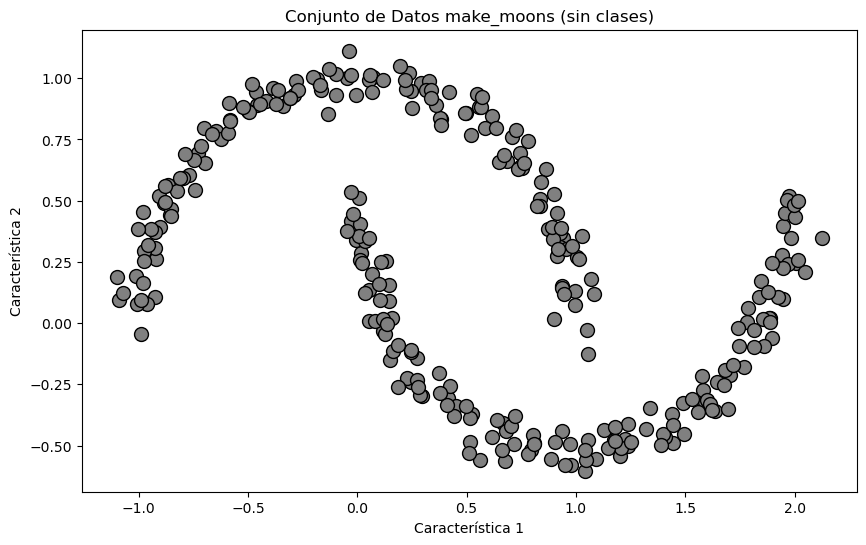

In [4]:
# Generar un conjunto de datos de ejemplo
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=0
)
print(f"La forma del vector X es: {X.shape}")

# Visualizar el conjunto de datos sin clases (previo al clustering)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, c='gray', marker='o', edgecolor='k')
plt.title('Conjunto de Datos make_moons (sin clases)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

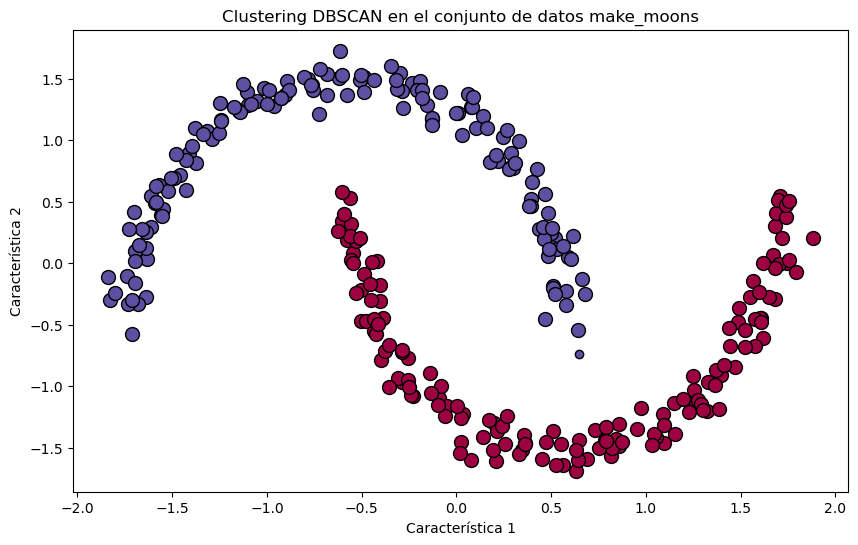

In [5]:
plot_eps = False

# Escalar las características
X = StandardScaler().fit_transform(X)

# Aplicar DBSCAN
db = DBSCAN(
    eps=0.3,
    min_samples=5,
    algorithm='kd_tree', # default es 'auto'
    metric='euclidean'
).fit(X)

labels = db.labels_

# Identificar puntos centrales y puntos frontera
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Graficar los resultados del clustering con DBSCAN
plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Negro usado para el ruido.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    # Puntos centrales
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10)

    # Puntos frontera
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)

    # Dibujar el círculo de epsilon alrededor de los puntos frontera
    if plot_eps:
        for point in xy:
            circle = plt.Circle(point, 0.3, color=tuple(col), fill=False, linestyle='--', linewidth=1)
            plt.gca().add_patch(circle)

plt.title('Clustering DBSCAN en el conjunto de datos make_moons')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

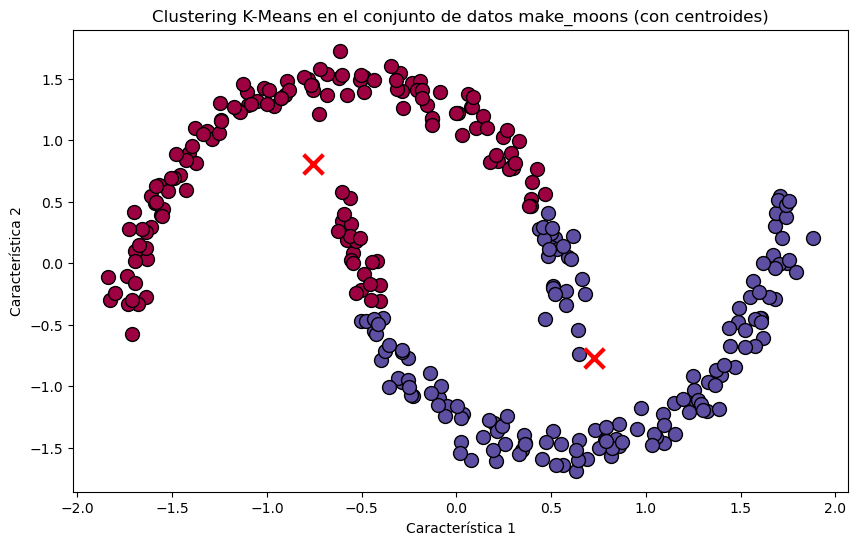

In [6]:
# Aplicar K-Means para mostrar el efecto de utilizar un modelo menos ideal.
kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    # tol=10
).fit(X)

labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

# Graficar los resultados del clustering con K-Means
plt.figure(figsize=(10, 6))
unique_labels = set(labels_kmeans)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    class_member_mask = (labels_kmeans == k)

    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10)

# Graficar los centroides
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3, zorder=10)
plt.title('Clustering K-Means en el conjunto de datos make_moons (con centroides)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()